# 📊 Estrategia para nota estructurada con Amazon (AMZN)

### 1. Librerias y dependencias

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('darkgrid')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


### 2. Configuración de periodos

Se analizará la acción desde diferentes periodos hasta el **Viernes 24 de Abril de 2026**, con el objetivo de analizar su  comportamiento. 

1. Desde Enero 2026 (Principios de Año)
2. Desde el 27 de Febrero de 2026 (días antes del inicio del conflicto EE.UU. e Irán)
3. Desde Enero 2025 (Principios del Años anterior)

Para tener una una perspecita más amplia se analizaran los siguientes periodos: 

4. Desde Enero 2023
5. Desde Enero 2025
    

In [2]:
TICKERS = ['AMZN']

PERIODOS = {
    'Corrida 1 — Desde Enero 2026': {
        'start':     '2026-01-02',
        'end':       '2026-04-24',
        'color':     '#2E86AB',
        'rf_series': 'DTB3'
    },
    'Corrida 2 — Desde 27 Feb 2026': {
        'start':     '2026-02-27',
        'end':       '2026-04-24',
        'color':     '#E84855',
        'rf_series': 'DTB3'
    },
    'Corrida 3 — Desde Enero 2025': {
        'start':     '2025-01-02',
        'end':       '2026-04-24',
        'color':     '#27AE60',
        'rf_series': 'DGS1'
    },
    'Corrida 4 — Desde Enero 2023': {
        'start':     '2023-01-02',
        'end':       '2026-04-24',
        'color':     '#F39C12',
        'rf_series': 'DGS3'
    },
    'Corrida 5 — Desde Enero 2021': {
        'start':     '2021-01-02',
        'end':       '2026-04-24',
        'color':     '#8E44AD',
        'rf_series': 'DGS5'
    }
}

print(f'📋 Acción seleccionada : {TICKERS}')
print(f'📅 Períodos configurados: {list(PERIODOS.keys())}')

📋 Acción seleccionada : ['AMZN']
📅 Períodos configurados: ['Corrida 1 — Desde Enero 2026', 'Corrida 2 — Desde 27 Feb 2026', 'Corrida 3 — Desde Enero 2025', 'Corrida 4 — Desde Enero 2023', 'Corrida 5 — Desde Enero 2021']


### 3. Descarga de datos desde Yahoo Finance (yfinance)

In [3]:
def descargar_precios(tickers, start, end):
    """Descarga precios ajustados de cierre desde yfinance."""
    print(f'  Descargando datos del {start} al {end}...')
    datos = yf.download(tickers, start=start, end=end,
                        auto_adjust=True, progress=False)
    precios = datos['Close']
    # Eliminar columnas con demasiados NaN
    precios = precios.dropna(axis=1, thresh=int(len(precios)*0.9))
    precios = precios.ffill().dropna()
    print(f'  ✅ {precios.shape[0]} días | {precios.shape[1]} acciones válidas')
    return precios

datos_periodos = {}
for nombre, cfg in PERIODOS.items():
    print(f'\n🔽 {nombre}')
    datos_periodos[nombre] = descargar_precios(TICKERS, cfg['start'], cfg['end'])


🔽 Corrida 1 — Desde Enero 2026
  Descargando datos del 2026-01-02 al 2026-04-24...
  ✅ 77 días | 1 acciones válidas

🔽 Corrida 2 — Desde 27 Feb 2026
  Descargando datos del 2026-02-27 al 2026-04-24...
  ✅ 39 días | 1 acciones válidas

🔽 Corrida 3 — Desde Enero 2025
  Descargando datos del 2025-01-02 al 2026-04-24...
  ✅ 327 días | 1 acciones válidas

🔽 Corrida 4 — Desde Enero 2023
  Descargando datos del 2023-01-02 al 2026-04-24...
  ✅ 829 días | 1 acciones válidas

🔽 Corrida 5 — Desde Enero 2021
  Descargando datos del 2021-01-02 al 2026-04-24...
  ✅ 1332 días | 1 acciones válidas


#### 3.1 Agregar último precio manual (2026-04-24)

Dentro de la request a yahoo finance no venia el último día a analizar, por lo que se pondrá manualmente dentro del dataset

In [4]:
FECHA_MANUAL  = pd.Timestamp('2026-04-24')
PRECIO_MANUAL = 424.62

for nombre, precios in datos_periodos.items():
    if FECHA_MANUAL not in precios.index:
        fila = pd.DataFrame(
            {ticker: PRECIO_MANUAL for ticker in precios.columns},
            index=[FECHA_MANUAL]
        )
        datos_periodos[nombre] = pd.concat([precios, fila]).sort_index()
        print(f'✅ {nombre}: precio {FECHA_MANUAL.date()} = ${PRECIO_MANUAL} agregado')
    else:
        print(f'ℹ️  {nombre}: {FECHA_MANUAL.date()} ya existe, no se modificó')

✅ Corrida 1 — Desde Enero 2026: precio 2026-04-24 = $424.62 agregado
✅ Corrida 2 — Desde 27 Feb 2026: precio 2026-04-24 = $424.62 agregado
✅ Corrida 3 — Desde Enero 2025: precio 2026-04-24 = $424.62 agregado
✅ Corrida 4 — Desde Enero 2023: precio 2026-04-24 = $424.62 agregado
✅ Corrida 5 — Desde Enero 2021: precio 2026-04-24 = $424.62 agregado


### 4. Tasas libre de riesgo

Se usaran como tasa libre de riesgo / risk free `` rf `` los siguientes datos: 

**Los datos fueron recopilados de las data series de la FRED**

1. `` DTB3 `` - 3 Month Treasury Bill 
2. `` DTB6 `` - 6 Month Treasury Bill 
3. `` DGS1 `` - 1 Year Treasury
4. `` DGS3 `` - 3 Year Treasury
5. `` DGS5 `` - 5 Year Treasury

Cada libre de riesgo será usada para sus respectivos análisis con un rango de tiempo similar o igual a la duración del bono.

In [5]:
_dir = os.path.dirname(os.path.abspath('portafolio_minima_varianza.ipynb'))

def leer_tasa(archivo, columna, start, end):
    """Lee un CSV de FRED y devuelve la tasa promedio del período en decimal."""
    df = pd.read_csv(archivo, parse_dates=['observation_date'], index_col='observation_date')
    df = df.replace('.', float('nan')).astype(float)
    mascara = (df.index >= start) & (df.index <= end)
    promedio = df.loc[mascara, columna].dropna().mean()
    return promedio / 100

dtb3_file = os.path.join(_dir, 'DTB3.csv')
dgs1_file = os.path.join(_dir, 'DGS1.csv')

_archivos = {
    'DTB3': dtb3_file,
    'DTB6': os.path.join(_dir, 'DTB6.csv'),
    'DGS1': dgs1_file,
    'DGS3': os.path.join(_dir, 'DGS3.csv'),
    'DGS5': os.path.join(_dir, 'DGS5.csv'),
}

# RF_RATES indexado por nombre de período (evita overwrite entre corridas que comparten serie)
RF_RATES = {}
print('📈 TASAS LIBRES DE RIESGO POR PERÍODO')
print('=' * 60)
for nombre, cfg in PERIODOS.items():
    serie   = cfg['rf_series']
    archivo = _archivos[serie]
    tasa    = leer_tasa(archivo, serie, cfg['start'], cfg['end'])
    RF_RATES[nombre] = tasa
    print(f'  {nombre}')
    print(f'    Serie: {serie}  →  {tasa*100:.3f}%')

📈 TASAS LIBRES DE RIESGO POR PERÍODO
  Corrida 1 — Desde Enero 2026
    Serie: DTB3  →  3.598%
  Corrida 2 — Desde 27 Feb 2026
    Serie: DTB3  →  3.612%
  Corrida 3 — Desde Enero 2025
    Serie: DGS1  →  3.835%
  Corrida 4 — Desde Enero 2023
    Serie: DGS3  →  4.067%
  Corrida 5 — Desde Enero 2021
    Serie: DGS5  →  3.383%


### 5. Métricas por acción

Se analizan métricas de la acción durante cada periodo. Esto es más que nada informativo. 

Métricas a analizar:

1. `` std_anual `` - Desviación Estándar (%)
2. `` max_dd `` - Max Drawdown (%)
3. `` mayor_subida `` - (%)

In [6]:
def metricas_accion(precios):
    ret  = np.log(precios / precios.shift(1)).dropna()
    rows = []
    for ticker in precios.columns:
        p = precios[ticker]
        r = ret[ticker]
        std_anual    = r.std() * np.sqrt(252) * 100
        rolling_max  = p.cummax()
        max_dd       = ((p - rolling_max) / rolling_max * 100).min()
        mayor_subida = r.max() * 100
        rows.append({
            'Ticker':                   ticker,
            'Desv. Est. Anual (%)':     round(std_anual,    2),
            'Max Drawdown (%)':         round(max_dd,        2),
            'Mayor Subida Diaria (%)':  round(mayor_subida,  2)
        })
    return (pd.DataFrame(rows)
              .set_index('Ticker')
              .sort_values('Desv. Est. Anual (%)', ascending=False))

print('\n📊 MÉTRICAS DE LA ACCIÓN')
for nombre, precios in datos_periodos.items():
    print(f'\n{"─"*62}')
    print(f'  {nombre}')
    print(f'{"─"*62}')
    print(metricas_accion(precios).to_string())


📊 MÉTRICAS DE LA ACCIÓN

──────────────────────────────────────────────────────────────
  Corrida 1 — Desde Enero 2026
──────────────────────────────────────────────────────────────
        Desv. Est. Anual (%)  Max Drawdown (%)  Mayor Subida Diaria (%)
Ticker                                                                 
AMZN                   97.35            -19.64                    50.96

──────────────────────────────────────────────────────────────
  Corrida 2 — Desde 27 Feb 2026
──────────────────────────────────────────────────────────────
        Desv. Est. Anual (%)  Max Drawdown (%)  Mayor Subida Diaria (%)
Ticker                                                                 
AMZN                  132.01             -8.95                    50.96

──────────────────────────────────────────────────────────────
  Corrida 3 — Desde Enero 2025
──────────────────────────────────────────────────────────────
        Desv. Est. Anual (%)  Max Drawdown (%)  Mayor Subida Diaria 

---

## SECCIÓN — Modelo de Fama-French 5 factores + Momentum


#### 5.1. Descargar datos directos de Ken Fench

In [7]:
import io
import zipfile
import requests
import statsmodels.api as sm

def _descargar_ff_csv(url, skiprows):
    """Descarga un ZIP de Ken French, extrae el primer CSV y lo retorna como texto."""
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        nombre_csv = [n for n in z.namelist() if n.lower().endswith('.csv')][0]
        with z.open(nombre_csv) as f:
            contenido = f.read().decode('utf-8', errors='replace')
    lineas = contenido.splitlines()[skiprows:]
    return '\n'.join(lineas)

def _parsear_diario(texto, columna_fecha='Date'):
    """
    Parsea el bloque de datos diarios de un CSV de Ken French.
    Ignora líneas vacías y el footer de copyright.
    Convierte todos los factores a decimal (dividen /100).
    """
    filas = []
    col_names = None

    for linea in texto.splitlines():
        partes = linea.split(',')
        first = partes[0].strip()

        # Fila de datos: primer campo es fecha numérica de 8 dígitos (YYYYMMDD)
        if len(first) == 8:
            try:
                int(first)
                filas.append(partes)
                continue
            except ValueError:
                pass

        # Fila de encabezado: primer campo vacío, el resto son nombres de factores
        if col_names is None and first == '' and len(partes) >= 2:
            candidate = [p.strip() for p in partes[1:] if p.strip()]
            if candidate:
                col_names = candidate

    df = pd.DataFrame(filas)
    df.rename(columns={0: columna_fecha}, inplace=True)
    df[columna_fecha] = pd.to_datetime(df[columna_fecha].str.strip(), format='%Y%m%d')
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce') / 100
    df.set_index(columna_fecha, inplace=True)

    if col_names is not None and len(col_names) == len(df.columns):
        df.columns = col_names
    else:
        df.columns = [str(c).strip() for c in df.columns]

    return df.dropna()

URL_FF5 = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_5_Factors_2x3_daily_CSV.zip')
URL_MOM = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Momentum_Factor_daily_CSV.zip')

print('📥 Descargando Fama-French 5 factores (diario) desde Ken French...')
texto_ff5 = _descargar_ff_csv(URL_FF5, skiprows=3)
ff5_daily = _parsear_diario(texto_ff5)
print(f'   ✅ FF5  — {len(ff5_daily):,} obs  |  cols: {list(ff5_daily.columns)}')

print('📥 Descargando factor Momentum (diario) desde Ken French...')
texto_mom = _descargar_ff_csv(URL_MOM, skiprows=13)
mom_daily = _parsear_diario(texto_mom)
mom_daily.columns = ['MOM']
print(f'   ✅ MOM  — {len(mom_daily):,} obs  |  cols: {list(mom_daily.columns)}')

factores = ff5_daily.join(mom_daily, how='inner').sort_index()
print(f'\n✅ Factores combinados: {list(factores.columns)}')
print(f'   Rango disponible : {factores.index.min().date()} → {factores.index.max().date()}')
print(f'   Observaciones    : {len(factores):,}')

📥 Descargando Fama-French 5 factores (diario) desde Ken French...
   ✅ FF5  — 15,770 obs  |  cols: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
📥 Descargando factor Momentum (diario) desde Ken French...
   ✅ MOM  — 26,089 obs  |  cols: ['MOM']

✅ Factores combinados: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM']
   Rango disponible : 1963-07-01 → 2026-02-27
   Observaciones    : 15,770


### 5.2. Función para correr regresión de factores

In [8]:
"""#### 7.2. Función para correr la regresión Fama-French 5 + Momentum"""

def fama_french_5_mom(precios, ticker, factores, rf_anual):
    """
    Estima el modelo Fama-French 5 factores + Momentum sobre un período.
    Retorna None si no hay suficientes observaciones comunes.
    """
    serie = precios[ticker].squeeze()
    ret   = np.log(serie / serie.shift(1)).dropna()
    ret.name = ticker

    df = pd.concat([ret, factores], axis=1, join='inner').dropna()

    if len(df) < 10:
        return None

    df['ExcessRet'] = df[ticker] - df['RF']

    X = sm.add_constant(df[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']])
    y = df['ExcessRet']

    modelo = sm.OLS(y, X).fit()
    alpha_d = modelo.params['const']

    return {
        'ticker':       ticker,
        'n_obs':        int(modelo.nobs),
        'alpha_diario': alpha_d,
        'alpha_anual':  alpha_d * 252,
        'alpha_pvalue': modelo.pvalues['const'],
        'betas':        modelo.params.drop('const').to_dict(),
        'pvalues':      modelo.pvalues.drop('const').to_dict(),
        'r2':           modelo.rsquared,
        'r2_adj':       modelo.rsquared_adj,
        'rf_anual':     rf_anual,
        'modelo':       modelo,
    }

print('✅ Función Factores lista')

✅ Función Factores lista


#### 5.3. Aplicar el modelo a cada uno de los periodos

In [9]:
"""#### 7.3. Aplicar el modelo a cada uno de los períodos"""

ff_resultados = {}
print('\n📐 REGRESIÓN FAMA-FRENCH 5 + MOMENTUM POR PERÍODO')
print('=' * 70)

for nombre, precios in datos_periodos.items():
    cfg = PERIODOS[nombre]
    factores_periodo = factores.loc[cfg['start']:cfg['end']]

    if len(factores_periodo) < 10:
        print(f'\n  ⚠️  {nombre}: datos de Ken French no disponibles aún para este período '
              f'({len(factores_periodo)} obs) — se omite.')
        continue

    res = fama_french_5_mom(
        precios   = precios,
        ticker    = TICKERS[0],
        factores  = factores_periodo,
        rf_anual  = RF_RATES[nombre]
    )

    if res is None:
        print(f'\n  ⚠️  {nombre}: sin fechas comunes entre retornos y factores — se omite.')
        continue

    ff_resultados[nombre] = res

    print(f'\n  {nombre}')
    print(f'  {"─"*66}')
    print(f'    Observaciones    : {res["n_obs"]}')
    print(f'    R²               : {res["r2"]:.4f}   |   R² ajustado: {res["r2_adj"]:.4f}')
    print(f'    Alpha diario     : {res["alpha_diario"]*100:+.4f}%   '
          f'(p-value: {res["alpha_pvalue"]:.3f})')
    print(f'    Alpha anualizado : {res["alpha_anual"]*100:+.2f}%')
    print(f'    Betas (cargas factoriales):')
    for f, b in res['betas'].items():
        signif = ' ***' if res['pvalues'][f] < 0.01 else \
                 ' **'  if res['pvalues'][f] < 0.05 else \
                 ' *'   if res['pvalues'][f] < 0.10 else ''
        print(f'      β_{f:<7}= {b:+.4f}   (p={res["pvalues"][f]:.3f}){signif}')

print('\n  Significancia: *** p<0.01,  ** p<0.05,  * p<0.10')


📐 REGRESIÓN FAMA-FRENCH 5 + MOMENTUM POR PERÍODO

  Corrida 1 — Desde Enero 2026
  ──────────────────────────────────────────────────────────────────
    Observaciones    : 38
    R²               : 0.4336   |   R² ajustado: 0.3240
    Alpha diario     : +0.1700%   (p-value: 0.579)
    Alpha anualizado : +42.83%
    Betas (cargas factoriales):
      β_Mkt-RF = +0.8961   (p=0.030) **
      β_SMB    = +0.7665   (p=0.291)
      β_HML    = +0.2574   (p=0.619)
      β_RMW    = +1.1739   (p=0.039) **
      β_CMA    = -3.0705   (p=0.003) ***
      β_MOM    = -0.7149   (p=0.030) **

  ⚠️  Corrida 2 — Desde 27 Feb 2026: datos de Ken French no disponibles aún para este período (1 obs) — se omite.

  Corrida 3 — Desde Enero 2025
  ──────────────────────────────────────────────────────────────────
    Observaciones    : 288
    R²               : 0.5538   |   R² ajustado: 0.5443
    Alpha diario     : -0.0671%   (p-value: 0.436)
    Alpha anualizado : -16.91%
    Betas (cargas factoriales):
     

#### 7.4. Tabla resumen comparativa entre periodos

In [10]:
if ff_resultados:
    filas_ff = []
    for nombre, res in ff_resultados.items():
        etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre
        fila = {
            'Período':      etiqueta,
            'N obs':        res['n_obs'],
            'α anual (%)':  f'{res["alpha_anual"]*100:+.2f}',
            'α p-val':      f'{res["alpha_pvalue"]:.3f}',
            'β Mkt-RF':     f'{res["betas"]["Mkt-RF"]:+.3f}',
            'β SMB':        f'{res["betas"]["SMB"]:+.3f}',
            'β HML':        f'{res["betas"]["HML"]:+.3f}',
            'β RMW':        f'{res["betas"]["RMW"]:+.3f}',
            'β CMA':        f'{res["betas"]["CMA"]:+.3f}',
            'β MOM':        f'{res["betas"]["MOM"]:+.3f}',
            'R²':           f'{res["r2"]:.3f}',
            'R² aj.':       f'{res["r2_adj"]:.3f}',
        }
        filas_ff.append(fila)

    df_ff = pd.DataFrame(filas_ff).set_index('Período')
    print(f'\n📋 RESUMEN FAMA-FRENCH 5 + MOMENTUM — {TICKERS[0]}')
    print('=' * 70)
    print(df_ff.to_string())
else:
    print('\n⚠️  No hay períodos con datos de factores suficientes para mostrar tabla.')


📋 RESUMEN FAMA-FRENCH 5 + MOMENTUM — AMZN
                  N obs α anual (%) α p-val β Mkt-RF   β SMB   β HML   β RMW   β CMA   β MOM     R² R² aj.
Período                                                                                                   
Desde Enero 2026     38      +42.83   0.579   +0.896  +0.766  +0.257  +1.174  -3.070  -0.715  0.434  0.324
Desde Enero 2025    288      -16.91   0.436   +1.313  +0.007  -0.316  +0.206  -0.623  -0.231  0.554  0.544
Desde Enero 2023    790       -4.88   0.690   +1.299  -0.193  -0.360  -0.000  -0.857  -0.198  0.548  0.544
Desde Enero 2021   1293       -8.28   0.401   +1.267  -0.334  -0.187  -0.038  -0.697  -0.162  0.598  0.596


#### 7.5. Gráfico de visualización por factor de cada periodo

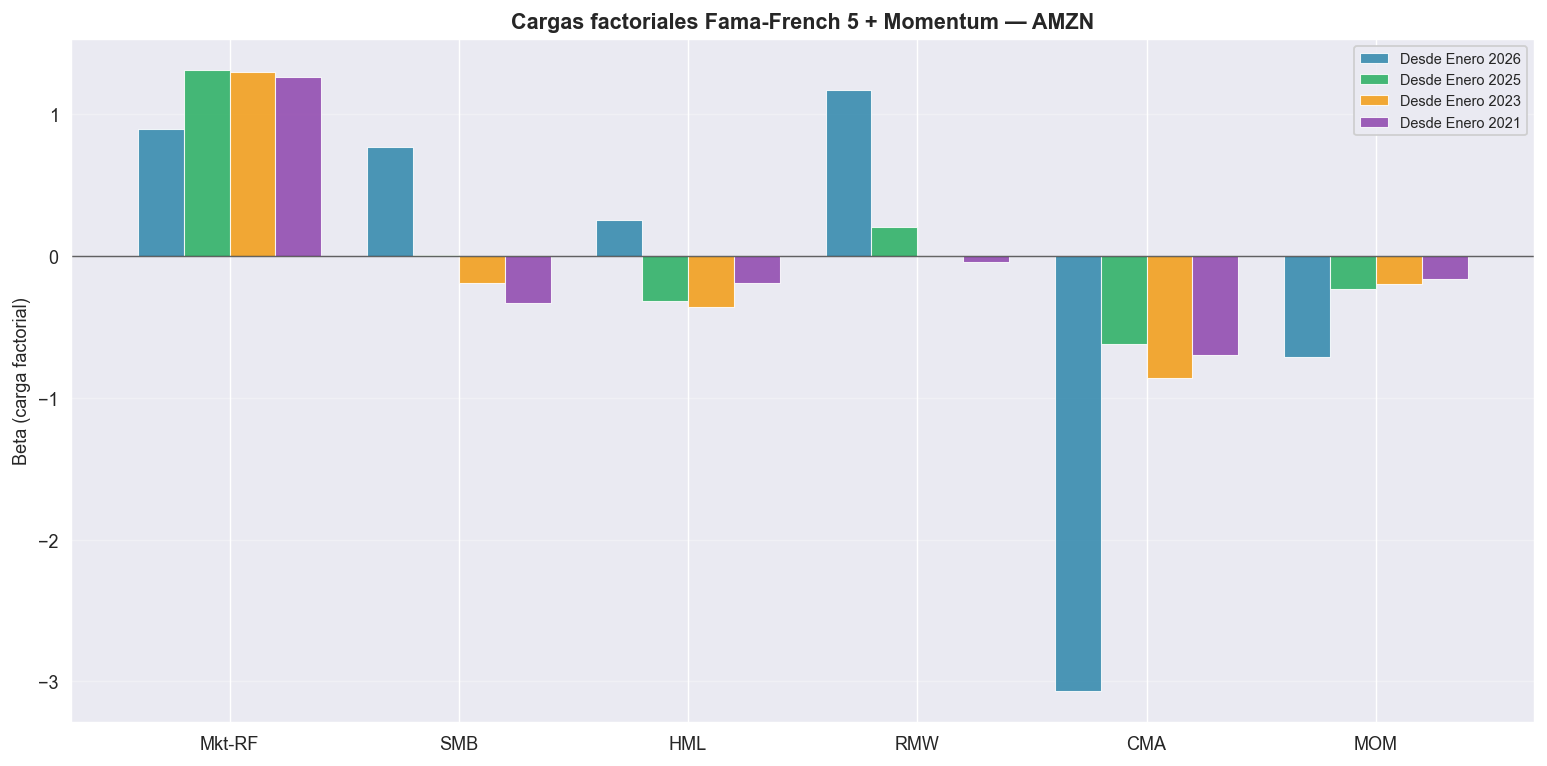


✅ Análisis Fama-French 5 + Momentum completado.



In [11]:
"""#### 7.5. Visualización de los betas por período"""

if ff_resultados:
    factores_plot = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
    nombres_ff    = list(ff_resultados.keys())

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(factores_plot))
    width = 0.8 / len(nombres_ff)

    for i, nombre in enumerate(nombres_ff):
        res    = ff_resultados[nombre]
        betas  = [res['betas'][f] for f in factores_plot]
        color  = PERIODOS[nombre]['color']
        label  = nombre.split('—')[1].strip() if '—' in nombre else nombre
        ax.bar(x + i*width, betas, width, label=label, color=color, alpha=0.85,
               edgecolor='white', linewidth=0.6)

    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.set_xticks(x + width*(len(nombres_ff)-1)/2)
    ax.set_xticklabels(factores_plot, fontsize=10)
    ax.set_ylabel('Beta (carga factorial)', fontsize=10)
    ax.set_title(f'Cargas factoriales Fama-French 5 + Momentum — {TICKERS[0]}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best', framealpha=0.9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print('\n✅ Análisis Fama-French 5 + Momentum completado.\n')

---
## 🎲 SECCIÓN — Simulación Monte Carlo (Movimiento Browniano Geométrico)

#### 6.1. Parámetros del Monte Carlo

In [12]:
N_SIM    = 10_000   # número de trayectorias
T_DAYS   = 80       # horizonte de proyección (días hábiles ~ 6 meses)
TICKER   = TICKERS[0]

# Percentiles a graficar
PERCENTILES = [5, 10, 25, 50, 75, 90, 95]

print(f'🎲 Monte Carlo — {TICKER}')
print(f'   Simulaciones : {N_SIM:,}')
print(f'   Horizonte    : {T_DAYS} días hábiles (~6 meses)')
print(f'   Percentiles  : {PERCENTILES}')

🎲 Monte Carlo — AMZN
   Simulaciones : 10,000
   Horizonte    : 80 días hábiles (~6 meses)
   Percentiles  : [5, 10, 25, 50, 75, 90, 95]


#### 6.2. Función de la simulación

In [13]:
def simular_gbm(precios, ticker, n_sim=10_000, t_days=63, rf_rate=0.0):
    """
    Simula trayectorias de precio con Movimiento Browniano Geométrico.
    Parámetros calibrados con retornos logarítmicos históricos.
    Devuelve matriz (n_sim x t_days+1) de precios simulados.
    """
    serie  = precios[ticker].squeeze()
    ret    = np.log(serie / serie.shift(1)).dropna()

    mu_d   = ret.mean()          # retorno diario medio
    sig_d  = ret.std()           # volatilidad diaria
    S0     = serie.iloc[-1]      # precio inicial = último precio observado

    dt = 1  # 1 día hábil

    # Genera shocks aleatorios (n_sim × t_days)
    rng    = np.random.default_rng(seed=42)
    eps    = rng.standard_normal((n_sim, t_days))

    # GBM: log-retorno diario ~ (mu - 0.5*sigma²)*dt + sigma*sqrt(dt)*eps
    drift  = (mu_d - 0.5 * sig_d**2) * dt
    shocks = sig_d * np.sqrt(dt) * eps
    log_ret = drift + shocks                          # (n_sim × t_days)

    # Acumular retornos y aplicar precio inicial
    cum_ret = np.cumsum(log_ret, axis=1)              # (n_sim × t_days)
    precios_sim = S0 * np.exp(
        np.hstack([np.zeros((n_sim, 1)), cum_ret])
    )                                                 # (n_sim × t_days+1)

    # Estadísticas anualizadas
    mu_anual  = mu_d  * 252
    sig_anual = sig_d * np.sqrt(252)
    sharpe    = (mu_anual - rf_rate) / sig_anual if sig_anual > 0 else 0

    return {
        'sim':       precios_sim,
        'S0':        S0,
        'mu_d':      mu_d,
        'sig_d':     sig_d,
        'mu_anual':  mu_anual,
        'sig_anual': sig_anual,
        'sharpe':    sharpe,
        'rf_rate':   rf_rate,
        'retornos':  ret
    }

print('✅ Función GBM lista')

✅ Función GBM lista


#### 6.3. Visualización del Monte Carlo

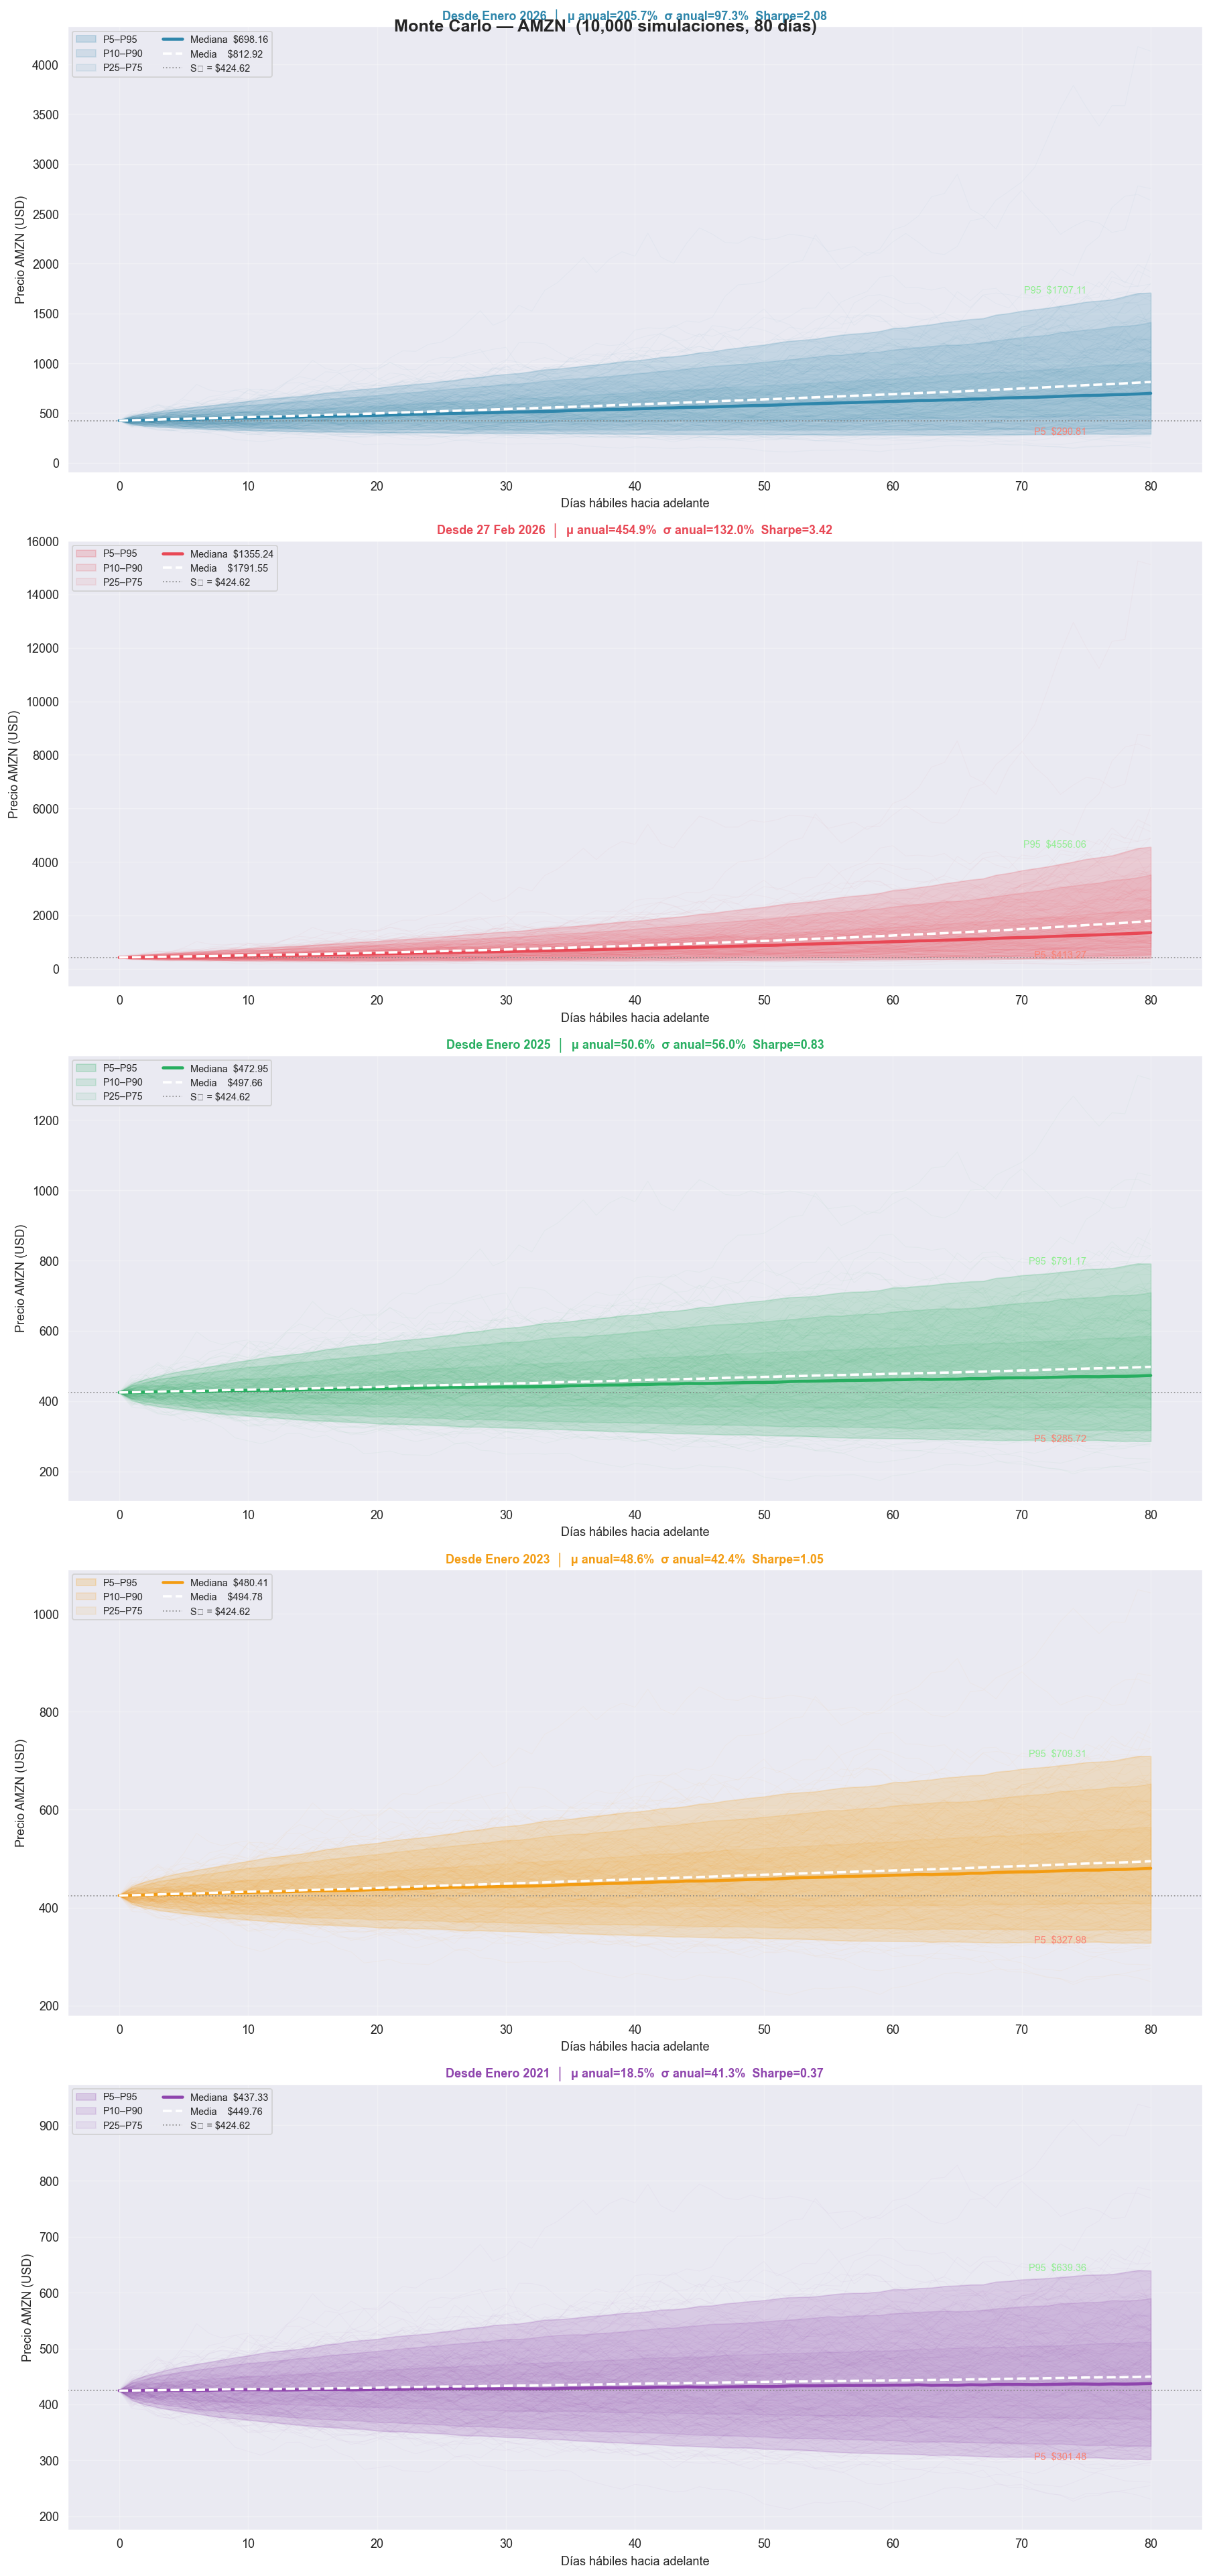

In [14]:
mc_resultados = {}
for nombre, cfg in PERIODOS.items():
    precios  = datos_periodos[nombre]
    rf_rate  = RF_RATES.get(nombre, 0.0)
    mc       = simular_gbm(precios, TICKER, N_SIM, T_DAYS, rf_rate)
    mc_resultados[nombre] = {**mc, 'color': cfg['color']}

    S0, sim = mc['S0'], mc['sim']
    S_final = sim[:, -1]

nombres_mc = list(mc_resultados.keys())
fig, axes  = plt.subplots(len(nombres_mc), 1,
                           figsize=(14, 6 * len(nombres_mc)), sharex=False)
if len(nombres_mc) == 1:
    axes = [axes]

fig.suptitle(f'Monte Carlo — {TICKER}  ({N_SIM:,} simulaciones, {T_DAYS} días)',
             fontsize=14, fontweight='bold')

BAND_ALPHA   = [0.10, 0.15, 0.20, 0.25]   # relleno para bandas 5-95, 10-90, 25-75
BAND_PAIRS   = [(5, 95), (10, 90), (25, 75)]
N_PATHS_SHOW = 200   # trayectorias individuales a pintar

dias = np.arange(T_DAYS + 1)

for ax, nombre in zip(axes, nombres_mc):
    mc    = mc_resultados[nombre]
    sim   = mc['sim']          # (n_sim × T_DAYS+1)
    S0    = mc['S0']
    color = mc['color']

    # --- Trayectorias individuales (muestra aleatoria) ---
    idx_show = np.random.default_rng(0).choice(N_SIM, N_PATHS_SHOW, replace=False)
    for i in idx_show:
        ax.plot(dias, sim[i], color=color, alpha=0.04, linewidth=0.6)

    # --- Bandas de percentiles ---
    band_colors = [0.55, 0.40, 0.25]   # opacidad decreciente hacia el centro
    for (lo, hi), bc in zip(BAND_PAIRS, band_colors):
        p_lo = np.percentile(sim, lo, axis=0)
        p_hi = np.percentile(sim, hi, axis=0)
        ax.fill_between(dias, p_lo, p_hi,
                        color=color, alpha=bc * 0.35,
                        label=f'P{lo}–P{hi}')

    # --- Mediana ---
    mediana = np.percentile(sim, 50, axis=0)
    ax.plot(dias, mediana, color=color, linewidth=2.5,
            label=f'Mediana  ${mediana[-1]:.2f}', zorder=5)

    # --- Media ---
    media_tray = sim.mean(axis=0)
    ax.plot(dias, media_tray, color='white', linewidth=2.0,
            linestyle='--', label=f'Media    ${media_tray[-1]:.2f}', zorder=6)

    # --- Precio inicial ---
    ax.axhline(S0, color='gray', linewidth=1.0, linestyle=':', alpha=0.8,
               label=f'S₀ = ${S0:.2f}')

    # --- Anotaciones clave ---
    S_final = sim[:, -1]
    ax.annotate(f'P5  ${np.percentile(S_final,5):.2f}',
                xy=(T_DAYS, np.percentile(S_final, 5)),
                xytext=(T_DAYS - 5, np.percentile(S_final, 5)),
                fontsize=8, color='salmon', ha='right')
    ax.annotate(f'P95  ${np.percentile(S_final,95):.2f}',
                xy=(T_DAYS, np.percentile(S_final, 95)),
                xytext=(T_DAYS - 5, np.percentile(S_final, 95)),
                fontsize=8, color='lightgreen', ha='right')

    ax.set_xlabel('Días hábiles hacia adelante')
    ax.set_ylabel(f'Precio {TICKER} (USD)')
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre
    ax.set_title(
        f'{etiqueta}  │  μ anual={mc["mu_anual"]*100:.1f}%  '
        f'σ anual={mc["sig_anual"]*100:.1f}%  Sharpe={mc["sharpe"]:.2f}',
        fontsize=10, color=color, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 6.4. Precios Finales y Cálculo de VaR

1. `` S_final `` - Vector con el precio simulado de cada trayectoria al último día del horizonte. Se obtiene tomando la última columna de la matriz de simulaciones GBM: `sim[:, -1]`.

2. `` S0 `` - Precio actual de la acción.

3. `` VaR_95 `` - Value at Risk al 95% de confianza. Es el precio por debajo del cual cae el peor 5% de los escenarios simulados. Representa la pérdida máxima esperada en condiciones adversas.

4. `` CVaR_95 `` - Expected Shortfall (Conditional VaR) al 95%. Es el precio promedio de los escenarios que ya cayeron por debajo del VaR 95%, es decir, el promedio del peor 5%. Cuantifica cuánto se pierde en los escenarios extremos.

5. `` prob_ganancia `` - Probabilidad de que el precio final supere al precio actual S₀. Se calcula como la fracción de simulaciones donde el precio final es mayor al inicial: `(S_final > S0).mean() * 100`.

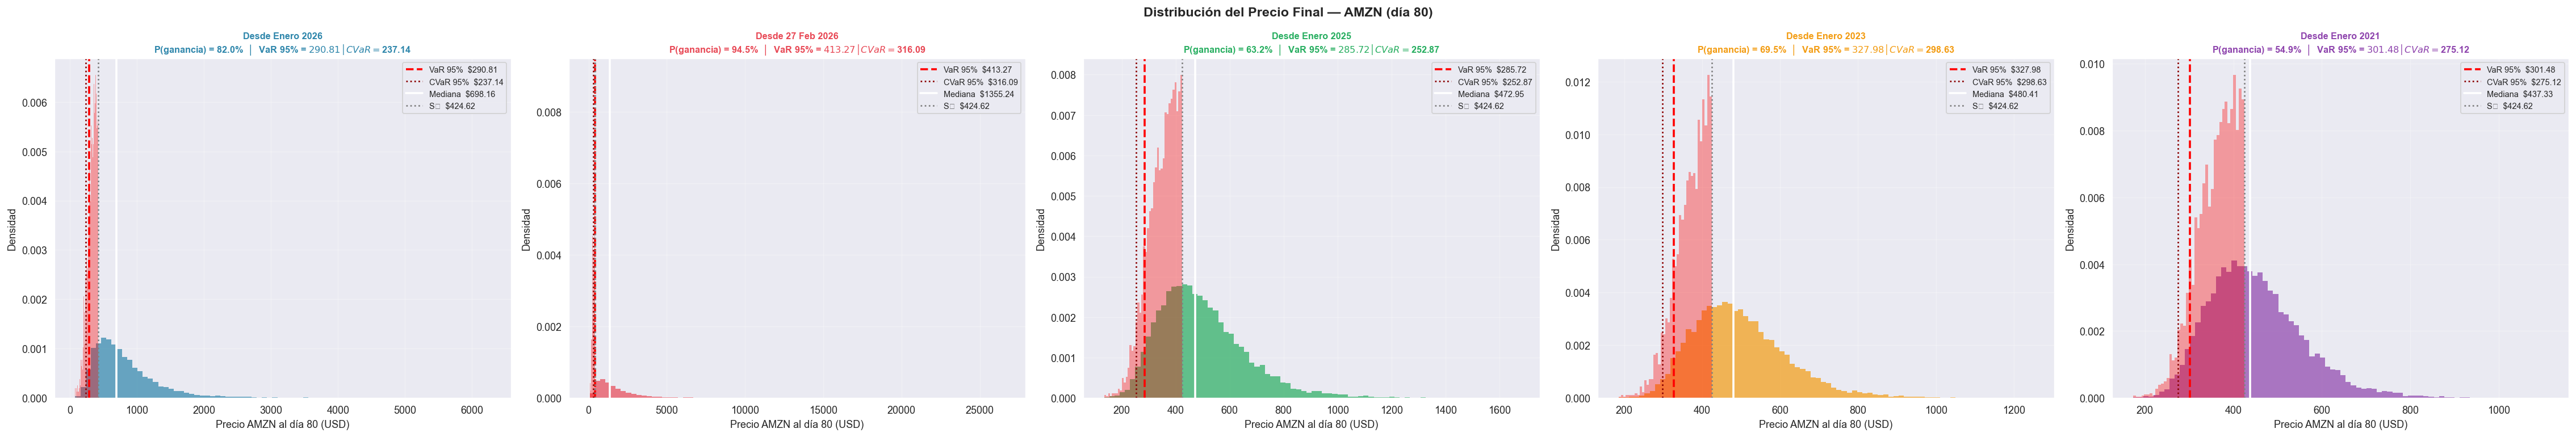

In [15]:
fig, axes = plt.subplots(1, len(nombres_mc),
                          figsize=(7 * len(nombres_mc), 6))
if len(nombres_mc) == 1:
    axes = [axes]

fig.suptitle(f'Distribución del Precio Final — {TICKER} (día {T_DAYS})',
             fontsize=13, fontweight='bold')

for ax, nombre in zip(axes, nombres_mc):
    mc      = mc_resultados[nombre]
    S_final = mc['sim'][:, -1]
    S0      = mc['S0']
    color   = mc['color']

    VaR_95  = np.percentile(S_final, 5)
    CVaR_95 = S_final[S_final <= VaR_95].mean()
    prob_ganancia = (S_final > S0).mean() * 100

    ax.hist(S_final, bins=80, color=color, alpha=0.7, edgecolor='none', density=True)

    # VaR y CVaR
    ax.axvline(VaR_95,  color='red',    linewidth=2,
               linestyle='--', label=f'VaR 95%  ${VaR_95:.2f}')
    ax.axvline(CVaR_95, color='darkred', linewidth=1.5,
               linestyle=':', label=f'CVaR 95%  ${CVaR_95:.2f}')

    # Mediana y S0
    ax.axvline(np.median(S_final), color='white', linewidth=2,
               linestyle='-', label=f'Mediana  ${np.median(S_final):.2f}')
    ax.axvline(S0, color='gray', linewidth=1.5,
               linestyle=':', label=f'S₀  ${S0:.2f}')

    # Zona de pérdida
    x_loss = S_final[S_final <= S0]
    if len(x_loss):
        ax.hist(x_loss, bins=40, color='red', alpha=0.35, edgecolor='none', density=True)

    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre
    ax.set_title(
        f'{etiqueta}\nP(ganancia) = {prob_ganancia:.1f}%  │  '
        f'VaR 95% = ${VaR_95:.2f}  │  CVaR = ${CVaR_95:.2f}',
        fontsize=9, color=color, fontweight='bold'
    )
    ax.set_xlabel(f'Precio {TICKER} al día {T_DAYS} (USD)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 6.5. Tabla resumen de estadísticas

In [16]:
filas = []
for nombre, mc in mc_resultados.items():
    S_final  = mc['sim'][:, -1]
    S0       = mc['S0']
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre

    mediana  = np.median(S_final)
    VaR_95   = np.percentile(S_final, 5)
    CVaR_95  = S_final[S_final <= VaR_95].mean()
    P95      = np.percentile(S_final, 95)

    med_pct  = (mediana / S0 - 1) * 100
    VaR_pct  = (VaR_95  / S0 - 1) * 100
    CVaR_pct = (CVaR_95 / S0 - 1) * 100
    P95_pct  = (P95     / S0 - 1) * 100

    filas.append({
        'Período':            etiqueta,
        'Precio Actual S₀':   f'${S0:.2f}',
        'μ diario hist. (%)':  f'{mc["mu_d"]*100:.4f}%',
        'μ anual hist. (%)':  f'{mc["mu_anual"]*100:.2f}%',
        'σ diaria (%)':     f'{mc["sig_d"]*100:.4f}%',
        'σ anual hist. (%)':  f'{mc["sig_anual"]*100:.2f}%',
        'Sharpe hist.':       f'{mc["sharpe"]:.3f}',
        f'Precio final - Media P{T_DAYS}':   f'${S_final.mean():.2f}',
        f'Mediana P{T_DAYS}': f'${mediana:.2f}  ({med_pct:+.1f}%)',
        'VaR 95%':            f'${VaR_95:.2f}  ({VaR_pct:.1f}%)',
        'CVaR 95%':           f'${CVaR_95:.2f}  ({CVaR_pct:.1f}%)',
        'P95':                f'${P95:.2f}  ({P95_pct:+.1f}%)',
        'P(ganancia)':        f'{(S_final > S0).mean()*100:.1f}%'
    })

df_mc = pd.DataFrame(filas).set_index('Período')

print(f'\n📋 RESUMEN MONTE CARLO — {TICKER}  (horizonte: {T_DAYS} días hábiles)')
print('=' * 80)
print(df_mc.T.to_string())
print(f'\n✅ Análisis completado exitosamente.')


📋 RESUMEN MONTE CARLO — AMZN  (horizonte: 80 días hábiles)
Período                      Desde Enero 2026    Desde 27 Feb 2026   Desde Enero 2025   Desde Enero 2023   Desde Enero 2021
Precio Actual S₀                      $424.62              $424.62            $424.62            $424.62            $424.62
μ diario hist. (%)                    0.8162%              1.8054%            0.2008%            0.1929%            0.0736%
μ anual hist. (%)                     205.67%              454.95%             50.60%             48.60%             18.54%
σ diaria (%)                          6.1322%              8.3157%            3.5288%            2.6724%            2.6047%
σ anual hist. (%)                      97.35%              132.01%             56.02%             42.42%             41.35%
Sharpe hist.                            2.076                3.419              0.835              1.050              0.367
Precio final - Media P80              $812.92             $1791.55      

#### 6.6. Gráficos resumen 

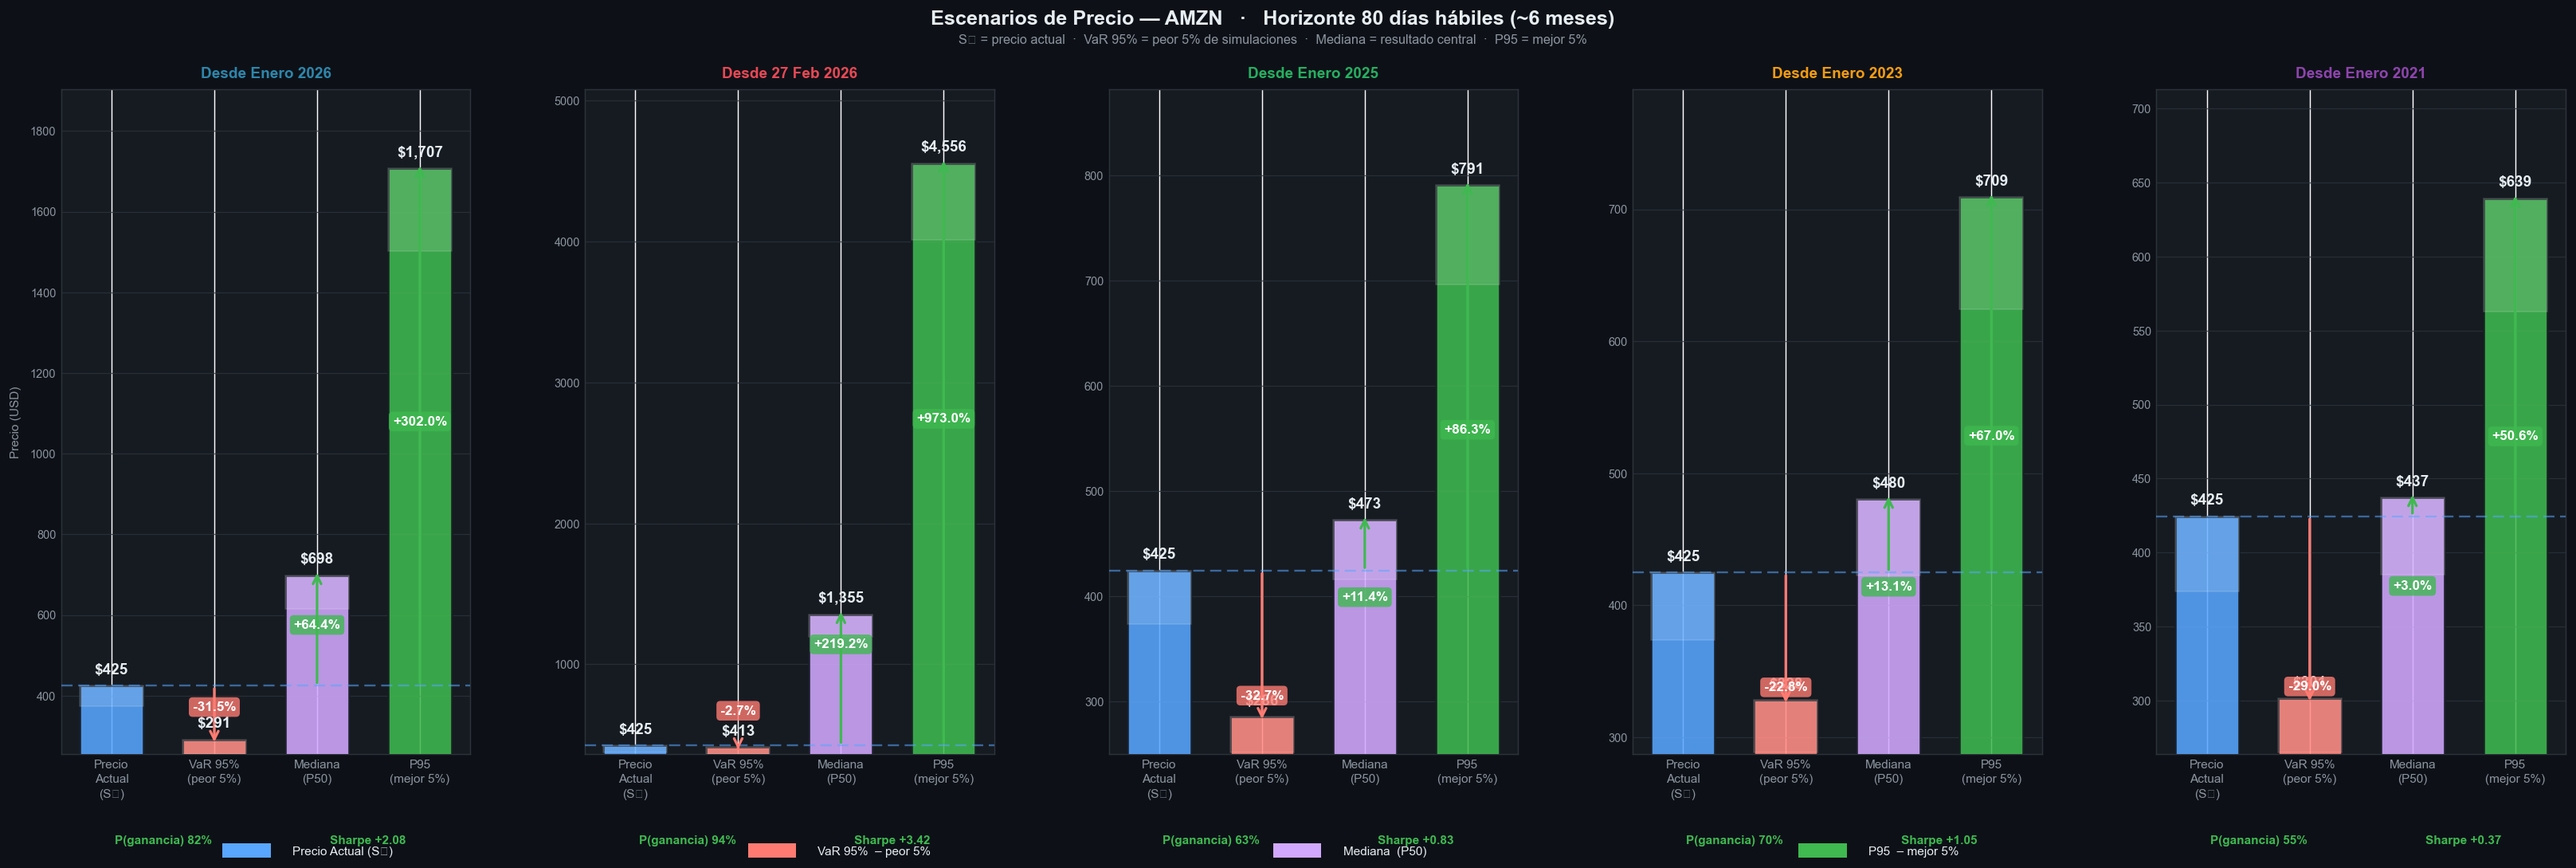

In [17]:
import matplotlib.patches as mpatches

nombres_mc = list(mc_resultados.keys())
n          = len(nombres_mc)

BG_DARK   = '#0D1117'
BG_PANEL  = '#161B22'
BG_STRIP  = '#1C2128'
GRID_CLR  = '#2D333B'
TXT_WHITE = '#E6EDF3'
TXT_MUTED = '#8B949E'

COL_S0  = '#58A6FF'
COL_VAR = '#FF7B72'
COL_MED = '#D2A8FF'
COL_P95 = '#3FB950'

ETIQUETAS_BAR  = ['Precio\nActual\n(S₀)', 'VaR 95%\n(peor 5%)', 'Mediana\n(P50)', 'P95\n(mejor 5%)']
COLORES_BARRAS = [COL_S0, COL_VAR, COL_MED, COL_P95]

fig = plt.figure(figsize=(5.2 * n, 8.5), facecolor=BG_DARK)
fig.patch.set_facecolor(BG_DARK)

# Título principal
fig.text(0.5, 0.985,
         f'Escenarios de Precio — {TICKER}   ·   Horizonte {T_DAYS} días hábiles (~6 meses)',
         ha='center', va='top', fontsize=14, fontweight='bold', color=TXT_WHITE)
fig.text(0.5, 0.958,
         'S₀ = precio actual  ·  VaR 95% = peor 5% de simulaciones  ·  '
         'Mediana = resultado central  ·  P95 = mejor 5%',
         ha='center', va='top', fontsize=9, color=TXT_MUTED)

# Leyenda: construida manualmente en la parte inferior de la figura
leyenda_items = [
    (COL_S0,  'Precio Actual (S₀)'),
    (COL_VAR, 'VaR 95%  – peor 5%'),
    (COL_MED, 'Mediana  (P50)'),
    (COL_P95, 'P95  – mejor 5%'),
]
total_w = 0.78
x_start = (1 - total_w) / 2
leg_y   = 0.028
sq_size = 0.018
gap     = total_w / len(leyenda_items)
for k, (clr, lbl) in enumerate(leyenda_items):
    xk = x_start + k * gap
    fig.add_artist(plt.Rectangle((xk, leg_y - 0.005), sq_size, sq_size * 0.9,
                                  transform=fig.transFigure,
                                  facecolor=clr, edgecolor='none', zorder=10,
                                  clip_on=False))
    fig.text(xk + sq_size + 0.008, leg_y + 0.001, lbl,
             ha='left', va='center', fontsize=8.5,
             color=TXT_WHITE, transform=fig.transFigure)

# ── Subplots ────────────────────────────────────────────────────
# top=0.895 deja margen suficiente para las dos líneas de título de figura
# bottom=0.14 da espacio para las etiquetas P(ganancia)/Sharpe debajo del eje
fig.subplots_adjust(top=0.895, bottom=0.14, left=0.05,
                    right=0.98, wspace=0.28)
axes = [fig.add_subplot(1, n, i + 1) for i in range(n)]

for ax, nombre in zip(axes, nombres_mc):
    mc      = mc_resultados[nombre]
    S_final = mc['sim'][:, -1]
    S0      = mc['S0']
    color   = mc['color']

    VaR_95  = np.percentile(S_final, 5)
    mediana = np.median(S_final)
    P95     = np.percentile(S_final, 95)
    prob_g  = (S_final > S0).mean() * 100
    VaR_pct = (VaR_95  / S0 - 1) * 100
    med_pct = (mediana  / S0 - 1) * 100
    P95_pct = (P95      / S0 - 1) * 100
    sharpe  = mc['sharpe']

    valores = [S0, VaR_95, mediana, P95]
    pcts    = [None, VaR_pct, med_pct, P95_pct]

    # Límites del eje: dejar margen arriba y abajo sin tira interna
    ymin_calc = min(valores) * 0.875
    ymax_calc = max(valores) * 1.115
    yrange    = ymax_calc - ymin_calc

    # Centro visible de cada barra para el badge %
    badge_floor = ymin_calc + yrange * 0.05

    # ── Estética del panel ────────────────────────────────────
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_CLR)
        spine.set_linewidth(0.8)

    # ── Barras ────────────────────────────────────────────────
    x_pos = np.arange(len(valores))
    bars  = ax.bar(x_pos, valores, color=COLORES_BARRAS,
                   alpha=0.88, edgecolor=BG_PANEL, linewidth=1.5,
                   width=0.62, zorder=3)

    # Brillo superior de cada barra
    for bar in bars:
        h, bx, bw = bar.get_height(), bar.get_x(), bar.get_width()
        ax.add_patch(plt.Rectangle(
            (bx, h * 0.88), bw, h * 0.12,
            color='white', alpha=0.12, zorder=4, clip_on=True
        ))

    # Línea de referencia en S₀
    ax.axhline(S0, color=COL_S0, linewidth=1.3,
               linestyle=(0, (6, 3)), alpha=0.55, zorder=5)

    # Flechas desde S₀ hacia cada barra
    for x_idx, (val, pct) in enumerate(zip(valores[1:], pcts[1:]), start=1):
        if pct is None:
            continue
        arrow_clr = COL_VAR if pct < 0 else COL_P95
        offset    = yrange * 0.008 * np.sign(val - S0)
        ax.annotate('',
            xy=(x_idx, val + offset), xytext=(x_idx, S0),
            arrowprops=dict(arrowstyle='->', color=arrow_clr,
                            lw=1.8, mutation_scale=14,
                            connectionstyle='arc3,rad=0.0'),
            zorder=6)

    # Etiquetas de precio encima de cada barra
    for bar, val, pct, clr in zip(bars, valores, pcts, COLORES_BARRAS):
        xc = bar.get_x() + bar.get_width() / 2
        ax.text(xc, bar.get_height() + yrange * 0.013,
                f'${val:,.0f}',
                ha='center', va='bottom', fontsize=10.5,
                fontweight='bold', color=TXT_WHITE, zorder=7)

        # Badge % en el centro de cada barra, respetando badge_floor
        if pct is not None:
            badge_clr = COL_VAR if pct < 0 else COL_P95
            sign      = '+' if pct >= 0 else ''
            badge_y   = (max(badge_floor, ymin_calc + yrange * 0.12) + bar.get_height()) / 2
            ax.text(xc, badge_y,
                    f'{sign}{pct:.1f}%',
                    ha='center', va='center', fontsize=9.5,
                    fontweight='bold', color='white', zorder=7,
                    bbox=dict(boxstyle='round,pad=0.28',
                              facecolor=badge_clr, alpha=0.80,
                              edgecolor='none'))

    # ── Ejes ──────────────────────────────────────────────────
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ETIQUETAS_BAR, fontsize=8.5,
                       color=TXT_MUTED, linespacing=1.4)
    ax.yaxis.set_tick_params(labelsize=8, labelcolor=TXT_MUTED, length=0)
    ax.xaxis.set_tick_params(length=0)
    ax.grid(True, axis='y', color=GRID_CLR, linewidth=0.7,
            linestyle='-', alpha=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(ymin_calc, ymax_calc)

    # Título del panel (color por período)
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre
    ax.set_title(etiqueta, fontsize=10.5, fontweight='bold',
                 color=color, pad=8)

    # ── P(ganancia) y Sharpe debajo del eje X (fuera del área de barras) ─
    pg_clr = COL_P95 if prob_g >= 50 else COL_VAR
    sh_clr = COL_P95 if sharpe  >= 0  else COL_VAR

    ax.text(0.25, -0.13, f'P(ganancia) {prob_g:.0f}%',
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color=pg_clr,
            transform=ax.transAxes, clip_on=False)
    ax.text(0.75, -0.13, f'Sharpe {sharpe:+.2f}',
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color=sh_clr,
            transform=ax.transAxes, clip_on=False)

    if ax is axes[0]:
        ax.set_ylabel('Precio (USD)', fontsize=8.5,
                      color=TXT_MUTED, labelpad=6)

plt.show()

---
## 🎯 SECCIÓN — Probabilidad de mantenerse por debajo de n precio ($)

📊 PROBABILIDAD DE QUE AMZN CIERRE POR DEBAJO DE $300
   Horizonte: 80 días hábiles (~6 meses)  |  Simulaciones: 10,000

  Desde Enero 2026
    P(precio < $300)  =    5.8%   ██
    P(precio ≥ $300)  =   94.2%

  Desde 27 Feb 2026
    P(precio < $300)  =    1.7%   
    P(precio ≥ $300)  =   98.3%

  Desde Enero 2025
    P(precio < $300)  =    6.9%   ███
    P(precio ≥ $300)  =   93.1%

  Desde Enero 2023
    P(precio < $300)  =    2.1%   █
    P(precio ≥ $300)  =   97.9%

  Desde Enero 2021
    P(precio < $300)  =    4.7%   ██
    P(precio ≥ $300)  =   95.3%


📋 TABLA RESUMEN
                   P(< $300) %  P(≥ $300) %
Período                                    
Desde Enero 2026          5.76        94.24
Desde 27 Feb 2026         1.74        98.26
Desde Enero 2025          6.94        93.06
Desde Enero 2023          2.11        97.89
Desde Enero 2021          4.69        95.31


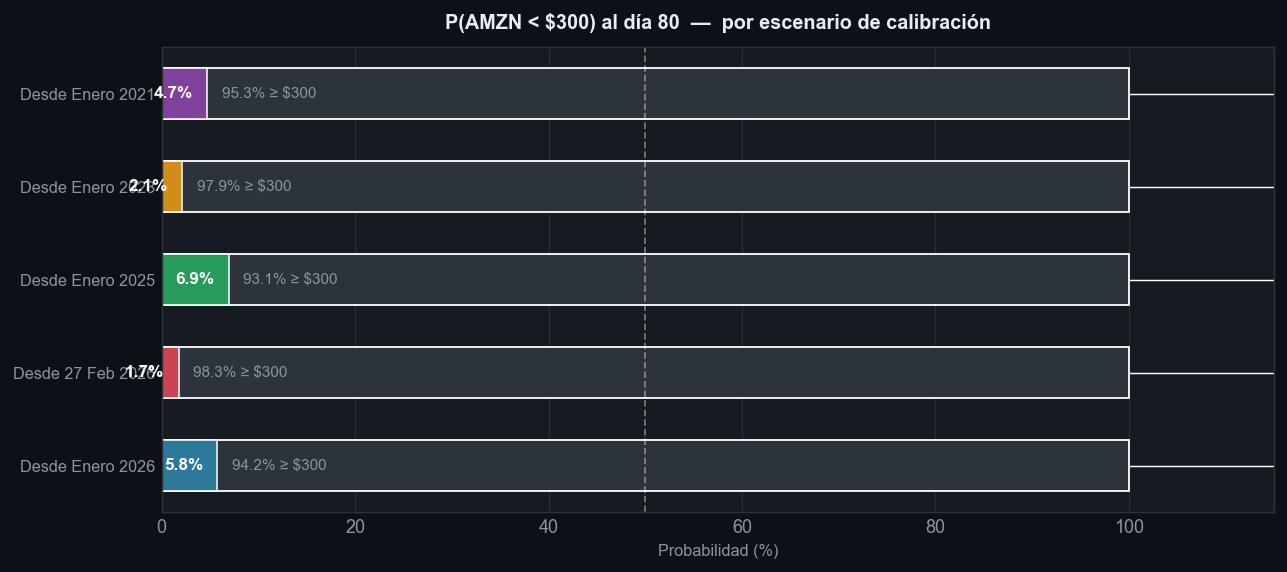

In [20]:
BARRERA = 300.0   # nivel de interés para la nota estructurada

print(f'📊 PROBABILIDAD DE QUE AMZN CIERRE POR DEBAJO DE ${BARRERA:.0f}')
print(f'   Horizonte: {T_DAYS} días hábiles (~6 meses)  |  Simulaciones: {N_SIM:,}')
print('=' * 65)

filas_barrera = []
for nombre, mc in mc_resultados.items():
    S_final  = mc['sim'][:, -1]
    S0       = mc['S0']
    etiqueta = nombre.split('—')[1].strip() if '—' in nombre else nombre

    prob_bajo   = (S_final < BARRERA).mean() * 100
    prob_arriba = 100 - prob_bajo

    filas_barrera.append({
        'Período':                  etiqueta,
        f'P(< ${BARRERA:.0f}) %':  round(prob_bajo,   2),
        f'P(≥ ${BARRERA:.0f}) %':  round(prob_arriba, 2),
    })

    barra_visual = '█' * int(prob_bajo / 2)
    print(f'\n  {etiqueta}')
    print(f'    P(precio < ${BARRERA:.0f})  =  {prob_bajo:5.1f}%   {barra_visual}')
    print(f'    P(precio ≥ ${BARRERA:.0f})  =  {prob_arriba:5.1f}%')

df_barrera = pd.DataFrame(filas_barrera).set_index('Período')
print(f'\n\n📋 TABLA RESUMEN')
print('=' * 65)
print(df_barrera.to_string())

# ── Gráfico de barras horizontales ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

etiquetas   = df_barrera.index.tolist()
probs_bajo  = df_barrera[f'P(< ${BARRERA:.0f}) %'].values
probs_arr   = df_barrera[f'P(≥ ${BARRERA:.0f}) %'].values
colores     = [PERIODOS[n]['color'] for n in mc_resultados.keys()]

y_pos = np.arange(len(etiquetas))

# Barra de fondo (100%)
ax.barh(y_pos, [100]*len(etiquetas), color='#2D333B', height=0.55, zorder=1)

# Barra de probabilidad < 520
bars = ax.barh(y_pos, probs_bajo, color=colores, alpha=0.85, height=0.55, zorder=2)

# Línea de referencia en 50%
ax.axvline(50, color='white', linewidth=1.0, linestyle='--', alpha=0.4)

# Etiquetas de porcentaje dentro/fuera de la barra
for i, (pb, pa, clr) in enumerate(zip(probs_bajo, probs_arr, colores)):
    ax.text(pb - 1.5, i, f'{pb:.1f}%', ha='right', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    ax.text(pb + 1.5, i, f'{pa:.1f}% ≥ ${BARRERA:.0f}', ha='left', va='center',
            fontsize=8.5, color='#8B949E')

ax.set_yticks(y_pos)
ax.set_yticklabels(etiquetas, fontsize=9, color='#E6EDF3')
ax.set_xlabel('Probabilidad (%)', fontsize=9, color='#8B949E')
ax.set_xlim(0, 115)
ax.set_title(
    f'P(AMZN < ${BARRERA:.0f}) al día {T_DAYS}  —  por escenario de calibración',
    fontsize=11, fontweight='bold', color='#E6EDF3', pad=10
)
ax.tick_params(colors='#8B949E', length=0)
for spine in ax.spines.values():
    spine.set_edgecolor('#2D333B')
ax.grid(True, axis='x', color='#2D333B', linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()